# Preprocessing and EDA for Hillary Mongare's LD50‑SMILES Dataset

This notebook:
1. Loads the dataset and inspects its structure.
2. Checks for missing values and ensures the target column is numeric.
3. Identifies duplicate SMILES and aggregates multiple measurements using the median (justification provided).
4. Computes molecular weights from SMILES (optional, for EDA).
5. Performs exploratory data analysis on the transformed LD50 values.

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 23.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the dataset

In [ ]:
file_path = '/content/drive/MyDrive/FYP/IRP/Data/Hillary Mongare LD50 SMILES Dataset/ld50-smiles-descriptors-dataset.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7397, 28)


,Name,SMILES,LD50,BertzCT,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HeavyAtomCount,...,NumHAcceptors,NumHDonors,NumHeteroatoms,RingCount,SMR_VSA10,SlogP_VSA12,SlogP_VSA5,VSA_EState4,VSA_EState9,qed
0,4-nitroaniline,Nc1ccc([N+](=O)[O-])cc1,2.265,242.429658,1.848642,1.103907,1.103907,0.596038,0.596038,10,...,3,1,4,1,11.374773,0.00000,0.000000,5.901255,0.000000,0.359544
1,4-nitrophenol,O=[N+]([O-])c1ccc(O)cc1,2.838,241.674771,1.773508,1.060528,1.060528,0.574349,0.574349,10,...,3,1,4,1,5.687386,0.00000,0.000000,-0.015926,0.000000,0.470728
2,1-(chloromethyl)-4-nitrobenzene,O=[N+]([O-])c1ccc(CCl)cc1,1.977,257.648013,2.324449,1.301462,1.610069,0.706751,0.884925,11,...,2,0,4,1,17.288326,11.60094,5.563451,0.982531,0.000000,0.389482
3,1-methoxy-4-nitrobenzene,COc1ccc([N+](=O)[O-])cc1,1.823,254.893126,1.955135,1.283242,1.283242,0.703937,0.703937,11,...,3,0,4,1,5.687386,0.00000,0.000000,0.074815,1.515046,0.478623
4,"benzene-1,4-dicarbonyl chloride",O=C(Cl)c1ccc(C(=O)Cl)cc1,1.910,283.334675,2.811331,1.338820,1.775256,0.732299,0.984275,12,...,2,0,4,1,33.686733,23.20188,20.715977,0.691358,0.000000,0.691354


## 2. Initial inspection and cleaning

In [ ]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7397 entries, 0 to 7396
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 7397 non-null   object 
 1   SMILES               7397 non-null   object 
 2   LD50                 7396 non-null   float64
 3   BertzCT              7392 non-null   float64
 4   Chi2v                7389 non-null   float64
 5   Chi3n                7389 non-null   float64
 6   Chi3v                7389 non-null   float64
 7   Chi4n                7393 non-null   float64
 8   Chi4v                7394 non-null   float64
 9   HeavyAtomCount       7397 non-null   int64  
 10  HeavyAtomMolWt       7396 non-null   float64
 11  Kappa3               7394 non-null   float64
 12  MaxPartialCharge     7392 non-null   float64
 13  MinAbsPartialCharge  7391 non-null   float64
 14  MinEStateIndex       7393 non-null   float64
 15  MinPartialCharge     7391 non-null   f

In [ ]:
# The target column is 'LD50'. Convert to numeric, coercing errors.
df['LD50'] = pd.to_numeric(df['LD50'], errors='coerce')
print(f"Rows with missing or non‑numeric target: {df['LD50'].isna().sum()}")

Rows with missing or non‑numeric target: 1


In [ ]:
# Drop rows with missing target
df = df.dropna(subset=['LD50']).copy()

In [ ]:
# Check for missing SMILES
print(f"Missing SMILES: {df['SMILES'].isna().sum()}")
df = df.dropna(subset=['SMILES']).copy()

print(f"Shape after cleaning: {df.shape}")

Missing SMILES: 0
Shape after cleaning: (7396, 28)


## 3. Check duplicates in SMILES

In [ ]:
# Count unique SMILES
print(f"Unique SMILES: {df['SMILES'].nunique()}")

# Show duplicated SMILES
duplicated_smiles = df[df.duplicated('SMILES', keep=False)]
print(f"Number of rows with duplicated SMILES: {len(duplicated_smiles)}")
duplicated_smiles.sort_values('SMILES').head(10)

Unique SMILES: 7341
Number of rows with duplicated SMILES: 102


,Name,SMILES,LD50,BertzCT,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HeavyAtomCount,...,NumHAcceptors,NumHDonors,NumHeteroatoms,RingCount,SMR_VSA10,SlogP_VSA12,SlogP_VSA5,VSA_EState4,VSA_EState9,qed
4777,"(e)-1,4-dibromobut-2-ene",BrC/C=C/CBr,3.455,34.812744,2.074972,0.344841,1.092487,0.125988,0.654654,6,...,0,0,2,0,31.859888,31.859888,0.000000,0.00000,0.000000,0.488276
5306,"(e)-1,4-dibromobut-2-ene",BrC/C=C/CBr,3.538,34.812744,2.074972,0.344841,1.092487,0.125988,0.654654,6,...,0,0,2,0,31.859888,31.859888,0.000000,0.00000,0.000000,0.488276
3372,(e)-but-2-enenitrile,C/C=C/C#N,2.127,66.207361,0.629099,0.241202,0.241202,0.074536,0.074536,5,...,1,0,1,0,0.000000,0.000000,6.923737,0.00000,0.000000,0.388843
720,(e)-but-2-enenitrile,C/C=C/C#N,2.604,66.207361,0.629099,0.241202,0.241202,0.074536,0.074536,5,...,1,0,1,0,0.000000,0.000000,6.923737,0.00000,0.000000,0.388843
294,ethyl (e)-but-2-enoate,C/C=C/C(=O)OCC,1.580,94.701658,1.252048,0.589346,0.589346,0.326454,0.326454,8,...,2,0,2,0,5.969305,0.000000,13.847474,0.00000,0.000000,0.397006
4334,ethyl (e)-but-2-enoate,C/C=C/C(=O)OCC,1.580,94.701658,1.252048,0.589346,0.589346,0.326454,0.326454,8,...,2,0,2,0,5.969305,0.000000,13.847474,0.00000,0.000000,0.397006
238,1-methoxy-4-[(z)-prop-1-enyl]benzene,C/C=C\c1ccc(OC)cc1,1.851,233.554619,2.273160,1.474919,1.474919,0.907472,0.907472,11,...,1,0,1,1,6.076020,0.000000,12.487189,1.20213,1.671296,0.626216
6441,1-methoxy-4-[(z)-prop-1-enyl]benzene,C/C=C\c1ccc(OC)cc1,2.995,233.554619,2.273160,1.474919,1.474919,0.907472,0.907472,11,...,1,0,1,1,6.076020,0.000000,12.487189,1.20213,1.671296,0.626216
2484,2-(oxiran-2-yl)oxirane,C1OC1C1CO1,2.613,53.948337,1.743570,1.132906,1.132906,0.540411,0.540411,6,...,2,0,2,2,0.000000,0.000000,0.000000,0.00000,0.000000,0.412165
1199,2-(oxiran-2-yl)oxirane,C1OC1C1CO1,3.043,53.948337,1.743570,1.132906,1.132906,0.540411,0.540411,6,...,2,0,2,2,0.000000,0.000000,0.000000,0.00000,0.000000,0.412165


## 4. Aggregate multiple measurements per SMILES (median)

**Justification**: LD50 values are typically log‑normally distributed, so the median (or geometric mean) is a robust central estimate that is less sensitive to outliers than the arithmetic mean. Using the median on the already log‑transformed `LD50` is equivalent to taking the median on the original scale, which preserves the location of the distribution without assuming a parametric form. This follows common practice in QSAR datasets (Karmaus et al., 2022).

In [ ]:
# Group by SMILES and compute median of LD50.
# Keep the first occurrence of the descriptor columns (they should be identical for the same SMILES)
# and also count the number of original measurements.

# First, list all descriptor columns (excluding SMILES, Name, LD50)
descriptor_cols = [col for col in df.columns if col not in ['SMILES', 'Name', 'LD50']]

# Aggregation dictionary: median for LD50, first for all other columns, count for number of measurements.
agg_dict = {'LD50': 'median'}
for col in descriptor_cols:
    agg_dict[col] = 'first'
agg_dict['Name'] = 'first'   # keep first chemical name
agg_dict['count'] = ('SMILES', 'count')  # number of rows per group

# Perform aggregation using named aggregation
agg_df = df.groupby('SMILES').agg(
    LD50_median=('LD50', 'median'),
    **{col: (col, 'first') for col in ['Name'] + descriptor_cols},
    n_measurements=('SMILES', 'count')
).reset_index()

# Rename back to original column names
agg_df = agg_df.rename(columns={'LD50_median': 'LD50'})

print(f"Number of unique compounds after aggregation: {len(agg_df)}")
agg_df.head()

# Show statistics of the number of measurements
agg_df['n_measurements'].describe()


Number of unique compounds after aggregation: 7341


,n_measurements
count,7341.000000
mean,1.007492
std,0.100806
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,4.000000


## 5. Compute molecular weights for further analysis

In [ ]:
def mol_weight_from_smiles(smiles):
    """Calculate molecular weight from SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Descriptors.MolWt(mol)

agg_df['MW'] = agg_df['SMILES'].apply(mol_weight_from_smiles)
print(f"Number with valid MW: {agg_df['MW'].notna().sum()}")

# Drop rows where MW could not be computed (optional, but recommended for consistency)
agg_df = agg_df.dropna(subset=['MW']).copy()
print(f"Shape after dropping invalid MW: {agg_df.shape}")

Number with valid MW: 7341
Shape after dropping invalid MW: (7341, 30)


## 6. Exploratory Data Analysis

In [ ]:
# Basic statistics of LD50
print("Statistics of LD50 (‑log₁₀(mol/kg)):")
print(agg_df['LD50'].describe())

Statistics of LD50 (‑log₁₀(mol/kg)):
count    7341.000000
mean        2.551766
std         0.951059
min         0.291000
25%         1.867000
50%         2.376000
75%         3.038000
max         7.207000
Name: LD50, dtype: float64


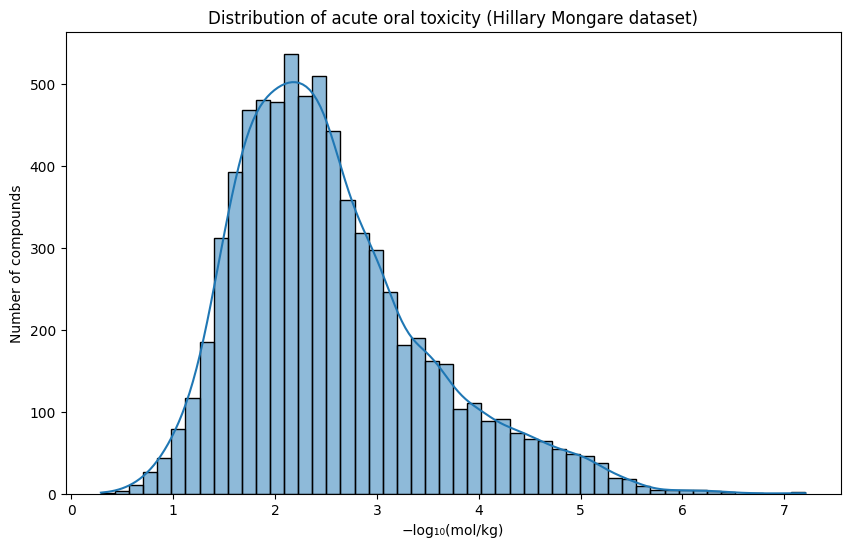

In [ ]:
# Histogram
plt.figure(figsize=(10,6))
sns.histplot(agg_df['LD50'], bins=50, kde=True)
plt.xlabel('−log₁₀(mol/kg)')
plt.ylabel('Number of compounds')
plt.title('Distribution of acute oral toxicity (Hillary Mongare dataset)')
plt.show()

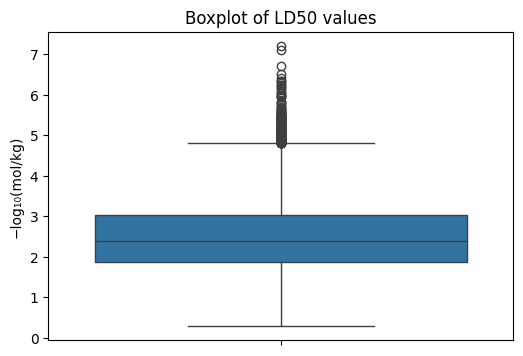

In [ ]:
# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(y=agg_df['LD50'])
plt.ylabel('−log₁₀(mol/kg)')
plt.title('Boxplot of LD50 values')
plt.show()

Save the processed dataset

In [ ]:
output_path = '/content/drive/MyDrive/FYP/IRP/Data/Hillary Mongare LD50 SMILES Dataset/ld50-smiles-descriptors_processed.csv'
agg_df.to_csv(output_path, index=False)
print(f"Saved processed data to {output_path}")

# For modeling, keep only SMILES and LD50 (plus any desired descriptors)
model_ready = agg_df[['SMILES', 'LD50']].copy()
model_ready.to_csv('/content/drive/MyDrive/FYP/IRP/Data/Hillary Mongare LD50 SMILES Dataset/ld50-smiles_model_ready.csv', index=False)

Saved processed data to /content/drive/MyDrive/FYP/IRP/Data/Hillary Mongare LD50 SMILES Dataset/ld50-smiles-descriptors_processed.csv


In [ ]:
len(agg_df['SMILES'].unique())

7341